## Завдання І, ІІ рівнів складності – максимально 7, 8 балів відповідно.
### Розробити програмний скрипт мовою Python що забезпечує аналіз властивостей і характеристик вихідних даних відповідно до етапів:
1. Модель генерації випадкової величини за заданим у табл.1 додатку 1 закону
розподілу;
2. Модель зміни (ідеальний тренд) досліджуваного процесу за заданим у табл.1
додатку 1 законом;
3. Адитивна модель статистичної вибірки відповідно до синтезованих в п.1,2 моделей
випадкової (стохастична) і невипадкової складових. Параметри закону розподілу та закону
зміни досліджуваного процесу обрати самостійно.
4. Визначення статистичних (числових) характеристик сформованих в п.1,3 вибірок
(дисперсія, середньоквадратичне відхилення, математичне очікування, гістограма закону
розподілу).
5. Визначення статистичних характеристик реальних даних, заданих файлом
Oschadbank (USD).xls за умов табл. 1 додатку 1.
6. Провести аналіз отриманих результатів та верифікацію розробленого скрипта.

# Завдання ІІІ рівня – максимально 10 балів.
1. Провести парсинг самостійно обраного сайту. Вміст даних, що підлягають парсингу
– обрати самостійно.
2. Результати парсингу зберегти у файлі. Тип файлу обрати самостійно.
3. Оцінити динаміку тренду реальних даних.
4. Здійснити визначення статистичних характеристик результатів парсингу.
5. Синтезувати та верифікувати модель даних, аналогічних за трендом і
статистичними характеристиками реальним даним, які є результатом парсингу.
6. Провести аналіз отриманих результатів.

P.s: *Завдання III рівня було обрано до виконання*

### 1. Провести парсинг самостійно обраного сайту. Вміст даних, що підлягають парсингу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
from sklearn.preprocessing import StandardScaler
import statsmodels.tsa.seasonal as seas
import statsmodels.api as sm
from bs4 import BeautifulSoup
from pathlib import Path

In [2]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df = df[(df['Date'] < '2024-12-31') & (df['Date'] > '2023-12-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

df

,Date,Buy,Sell
0,2024-01-01,42.2320,42.2499
1,2024-01-02,41.7985,41.8107
2,2024-01-03,41.6434,41.6559
3,2024-01-04,41.7846,41.8060
4,2024-01-05,41.7666,41.8175
...,...,...,...
256,2024-12-24,43.6261,43.6301
257,2024-12-25,43.5848,43.6140
258,2024-12-26,43.5449,43.5552
259,2024-12-27,43.7516,43.7703


### 2. Результати парсингу зберегти у файлі. Тип файлу обрати самостійно.

In [3]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


### 3. Оцінити динаміку тренду реальних даних.


In [4]:
def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')

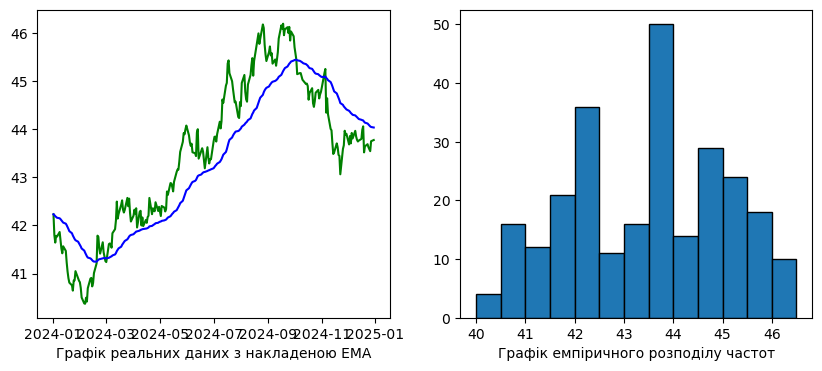

In [5]:
draw_plots(df, 'Date', 'Buy')

In [20]:
# Decomposition
df_decomposed = df.set_index('Date')
decomposition = seas.seasonal_decompose(x=df_decomposed['Buy'], period=5, model='additive')
df_decomposed = pd.concat([df_decomposed, decomposition.trend, decomposition.seasonal, decomposition.resid], axis=1)

residuals = decomposition.resid.dropna()
observed_values = decomposition.observed.loc[residuals.index]
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((observed_values - observed_values.mean()) **2 )

if ss_tot == 0:
    R2_decompose = 1.0
else:
    R2_decompose = 1 - (ss_res / ss_tot)

print(f"Показник R^2 для моделі декомпозиції: {R2_decompose:.4f}")

df_decomposed

Показник R^2 для моделі декомпозиції: 0.9937


,Buy,Sell,trend,seasonal,resid
Date,,,,,
2024-01-01,42.2320,42.2499,NaN,0.056736,NaN
2024-01-02,41.7985,41.8107,NaN,0.030723,NaN
2024-01-03,41.6434,41.6559,41.84502,-0.001000,-0.200620
2024-01-04,41.7846,41.8060,41.77128,-0.050321,0.063641
2024-01-05,41.7666,41.8175,41.74880,-0.036137,0.053937
...,...,...,...,...,...
2024-12-24,43.6261,43.6301,43.61830,0.030723,-0.022923
2024-12-25,43.5848,43.6140,43.63950,-0.001000,-0.053700
2024-12-26,43.5449,43.5552,43.65688,-0.050321,-0.061659


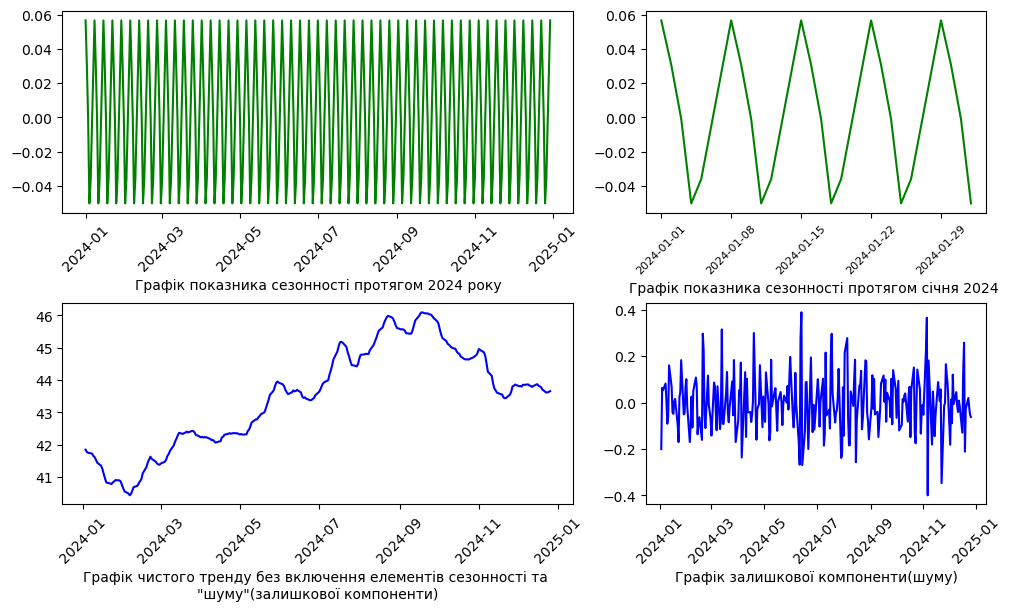

In [7]:
# Setting some additional parameters for the next plots
fig, ax = plt.subplots(2, 2, layout='constrained', width_ratios=[0.6, 0.4])
fig.set_figheight(6)
fig.set_figwidth(10)
ax[0][0].tick_params(axis='x', labelrotation=45)
ax[0][0].set_xlabel('Графік показника сезонності протягом 2024 року')
ax[0][1].set_xticks(ticks=df[::5]['Date'], labels=df[::5]['Date'].astype(str), rotation=45, size=8)
ax[0][1].set_xlabel('Графік показника сезонності протягом січня 2024 ')
ax[1][0].tick_params(axis='x', labelrotation=45)
ax[1][0].set_xlabel('Графік чистого тренду без включення елементів сезонності та \n"шуму"(залишкової компоненти)')
ax[1][1].tick_params(axis='x', labelrotation=45)
ax[1][1].set_xlabel('Графік залишкової компоненти(шуму)')
# fig.tight_layout()

ax[0][0].plot(df_decomposed['seasonal'], color='g')
ax[0][1].plot(df_decomposed['seasonal']['2024/01/01':'2024/02/01'], color='g', )
ax[1][0].plot(df_decomposed['trend'], color='b')
ax[1][1].plot(df_decomposed['resid'], color='b');

In [8]:
if df_decomposed.index.dtype != 'int64':
    df_decomposed.reset_index(inplace=True)
    df_decomposed.drop(columns=['Sell'], inplace=True)
df_decomposed

,Date,Buy,trend,seasonal,resid
0,2024-01-01,42.2320,NaN,0.056736,NaN
1,2024-01-02,41.7985,NaN,0.030723,NaN
2,2024-01-03,41.6434,41.84502,-0.001000,-0.200620
3,2024-01-04,41.7846,41.77128,-0.050321,0.063641
4,2024-01-05,41.7666,41.74880,-0.036137,0.053937
...,...,...,...,...,...
256,2024-12-24,43.6261,43.61830,0.030723,-0.022923
257,2024-12-25,43.5848,43.63950,-0.001000,-0.053700
258,2024-12-26,43.5449,43.65688,-0.050321,-0.061659
259,2024-12-27,43.7516,NaN,-0.036137,NaN


### 4. Здійснити визначення статистичних характеристик результатів парсингу.

In [9]:
# Normality of data
norm_df = df.copy().drop('Sell', axis=1)
norm_df[['Buy']] = StandardScaler().fit_transform(df[['Buy']])

y = norm_df['Buy']

x = np.arange(len(norm_df))
X_poly = pd.DataFrame({'x': x, 'x^2': x**2, 'x^3': x**3, 'x^4': x**4, 'x^5': x**5})

X_poly_const = sm.add_constant(X_poly)

model = sm.OLS(y, X_poly_const)
results = model.fit()
print(results.summary())

print(f'\nСереднє квадратичне відхилення реальних даних(стовпчика "Buy"): {df['Buy'].std()}')
print(f'Дисперсія реальних даних(стовпчика "Buy"): {df['Buy'].var()}')
print(f'Математичне сподівання(середнє значення стовпчика "Buy" реальних даних): {df['Buy'].mean()}')

print(f'\nСереднє квадратичне відхилення нормалізованих даних(стовпчика "Buy"): {norm_df['Buy'].std()}')
print(f'Дисперсія нормалізованих даних(стовпчика "Buy"): {norm_df['Buy'].var()}')
print(f'Математичне сподівання(середнє значення стовпчика "Buy" нормалізованих даних): {norm_df['Buy'].mean()}')

                            OLS Regression Results                            
Dep. Variable:                    Buy   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     582.4
Date:                Wed, 17 Sep 2025   Prob (F-statistic):          3.05e-137
Time:                        22:51:03   Log-Likelihood:                -41.569
No. Observations:                 261   AIC:                             95.14
Df Residuals:                     255   BIC:                             116.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4582      0.103    -14.138      0.0

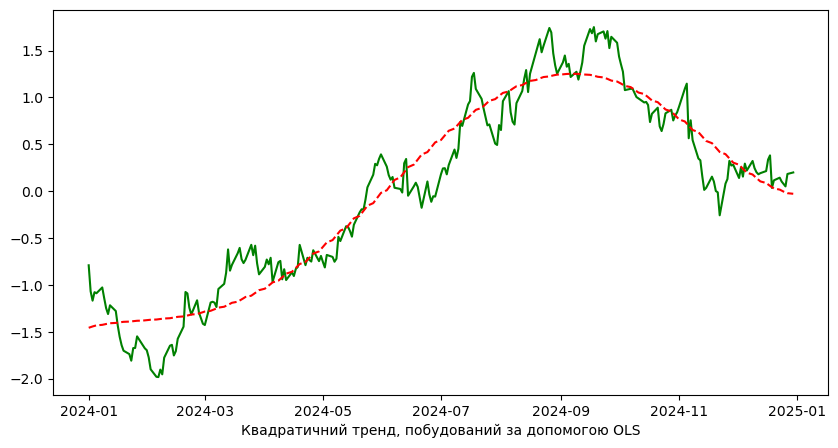

In [10]:
norm_df['OLS_trend'] = results.predict(X_poly_const)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(norm_df['Date'], norm_df['Buy'], label='Реальні дані', color='g')
ax.plot(norm_df['Date'], norm_df['OLS_trend'], label='Тренд OLS', color='r', linestyle='--')
ax.set_xlabel('Квадратичний тренд, побудований за допомогою OLS')
ax.plot();


### 5. Синтезувати та верифікувати модель даних, аналогічних за трендом і статистичними характеристиками реальним даним, які є результатом парсингу.
*Ця частина буде складатися з 2 етапів, бо алгоритмів, які ми будемо тут розглядати теж 2*

In [11]:
# Function for showing the trend and borders of resid
def trend_resid_show(dtf, col_resid_name, col_trend_name, model_name, axi):
    dtf[col_resid_name] = dtf['Buy'] - dtf[col_trend_name]
    model_resid_std = dtf[col_resid_name].std()
    dtf['upper_3sigma'] = dtf[col_trend_name] + 3 * model_resid_std
    dtf['lower_3sigma'] = dtf[col_trend_name] - 3 * model_resid_std
    print('Аномальні дані:')
    print(dtf[dtf[col_resid_name] > 3 * model_resid_std])

    # Deleting anomalies
    # dtf['Buy'] = dtf['Buy'].mask(dtf[col_resid_name] > 3 * model_resid_std, dtf[col_trend_name], axis=0)  # this line is for changing to the trend value
    dtf.drop(index=list(dtf[dtf[col_resid_name] > 3 * model_resid_std].index), inplace=True)

    # fig, ax = plt.subplots(figsize=(10, 5))

    axi.plot(dtf['Date'], dtf[col_trend_name], "r", label=model_name)
    axi.plot(dtf['Date'], dtf['Buy'], "b-", label="Real")
    axi.plot(dtf['Date'], dtf['upper_3sigma'], "r--")
    axi.plot(dtf['Date'], dtf['lower_3sigma'], "r--")
    axi.set_xlabel('Trend with real data')
    axi.legend(loc="best")

def gen_synthetic_data(dtf, col_resid_name, col_trend_name, model_name):
    # Synthesising synthetic data and applying it to the trend values
    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 5))
    trend_resid_show(dtf, col_resid_name, col_trend_name, model_name, ax[0])

    model_resid_std = dtf[col_resid_name].std()
    model_synthetic_noise = np.random.normal(loc=0, scale=model_resid_std, size=len(dtf))
    dtf['Synthetic_Buy'] = dtf[col_trend_name] + model_synthetic_noise

    ax[1].plot(dtf['Date'], dtf[col_trend_name], "r", label=model_name)
    ax[1].plot(dtf['Date'], dtf['Synthetic_Buy'], "y", label=f"Synthetic {model_name} model")
    ax[1].plot(dtf['Date'], dtf['upper_3sigma'], "r--")
    ax[1].plot(dtf['Date'], dtf['lower_3sigma'], "r--")
    ax[1].set_xlabel('Trend with synthetic data')
    ax[1].legend(loc="best")
    plt.show()

1. Отриманий за допомогою МНК та моделі OLS

Аномальні дані:
Empty DataFrame
Columns: [Date, Buy, OLS_trend, OLS_resid, upper_3sigma, lower_3sigma]
Index: []


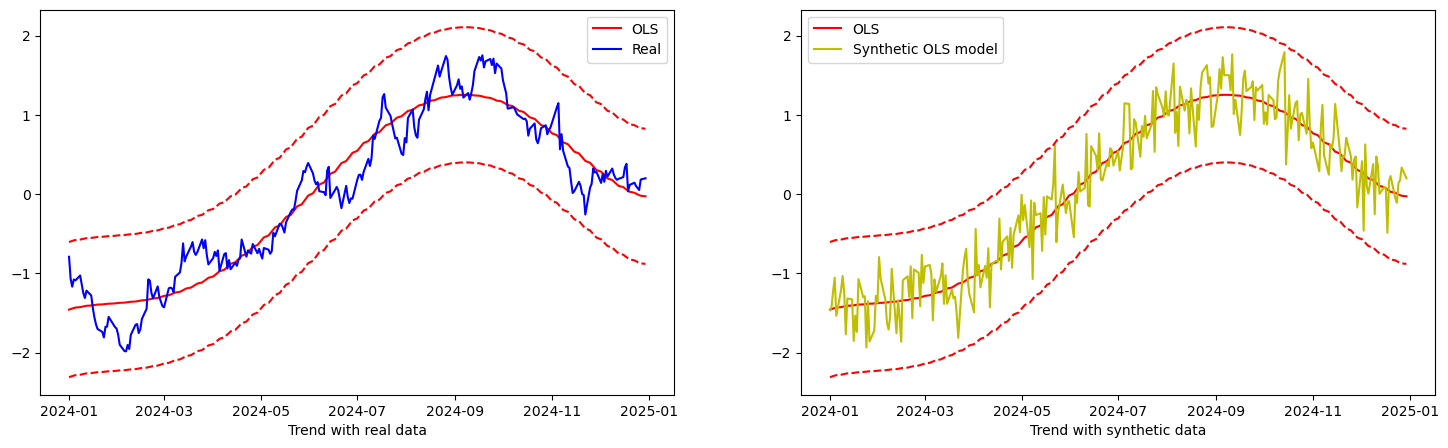

In [12]:
# First model
# trend_resid_show(norm_df, 'OLS_resid', 'OLS_trend', 'OLS')
gen_synthetic_data(norm_df, 'OLS_resid', 'OLS_trend', 'OLS')

2. Отриманий під час декомпозиції

Аномальні дані:
          Date     Buy     trend  seasonal    resid  upper_3sigma  \
221 2024-11-05  45.255  44.85788  0.030723  0.39712     45.249221   

     lower_3sigma  
221     44.466539  


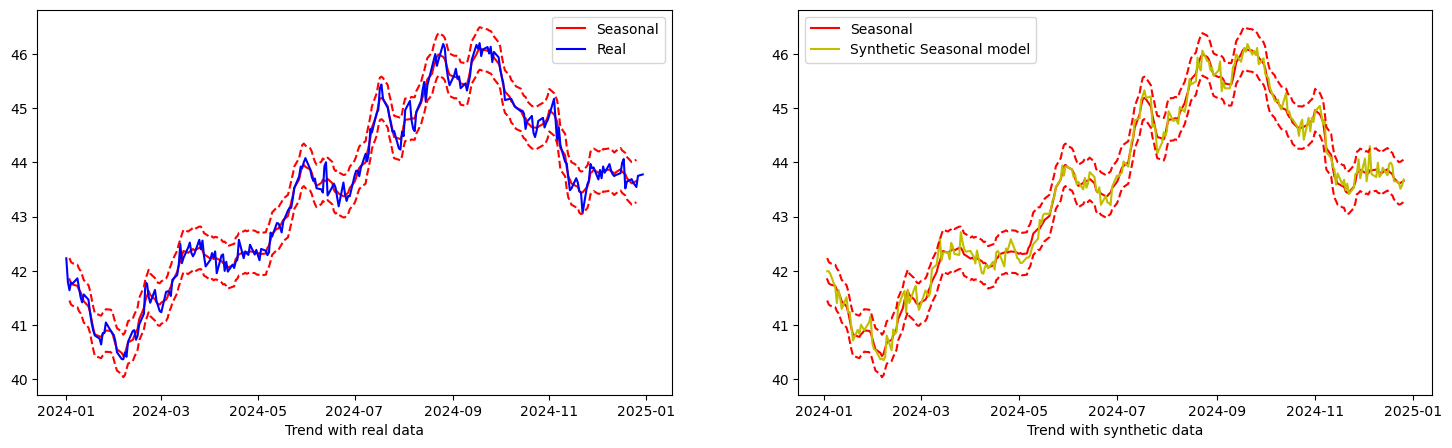

In [13]:
# Second model
# trend_resid_show(df_decomposed, 'resid', 'trend', 'Seasonal')
gen_synthetic_data(df_decomposed, 'resid', 'trend', 'Seasonal')

In [14]:
norm_df

,Date,Buy,OLS_trend,OLS_resid,upper_3sigma,lower_3sigma,Synthetic_Buy
0,2024-01-01,-0.791294,-1.458190,0.666896,-0.605310,-2.311069,-1.465679
1,2024-01-02,-1.069269,-1.450847,0.381578,-0.597968,-2.303727,-1.422423
2,2024-01-03,-1.168724,-1.444078,0.275354,-0.591198,-2.296957,-1.221785
3,2024-01-04,-1.078182,-1.437844,0.359662,-0.584965,-2.290724,-1.055552
4,2024-01-05,-1.089724,-1.432109,0.342385,-0.579230,-2.284989,-1.536003
...,...,...,...,...,...,...,...
256,2024-12-24,0.102651,0.005268,0.097382,0.858148,-0.847611,-0.109191
257,2024-12-25,0.076168,-0.004881,0.081049,0.847998,-0.857760,0.138909
258,2024-12-26,0.050583,-0.013888,0.064470,0.838992,-0.866767,0.175027
259,2024-12-27,0.183126,-0.021697,0.204822,0.831183,-0.874576,0.334795


In [15]:
df_decomposed

,Date,Buy,trend,seasonal,resid,upper_3sigma,lower_3sigma,Synthetic_Buy
0,2024-01-01,42.2320,NaN,0.056736,NaN,NaN,NaN,NaN
1,2024-01-02,41.7985,NaN,0.030723,NaN,NaN,NaN,NaN
2,2024-01-03,41.6434,41.84502,-0.001000,-0.20162,42.236361,41.453679,41.992797
3,2024-01-04,41.7846,41.77128,-0.050321,0.01332,42.162621,41.379939,41.993197
4,2024-01-05,41.7666,41.74880,-0.036137,0.01780,42.140141,41.357459,41.938420
...,...,...,...,...,...,...,...,...
256,2024-12-24,43.6261,43.61830,0.030723,0.00780,44.009641,43.226959,43.512564
257,2024-12-25,43.5848,43.63950,-0.001000,-0.05470,44.030841,43.248159,43.574011
258,2024-12-26,43.5449,43.65688,-0.050321,-0.11198,44.048221,43.265539,43.684154
259,2024-12-27,43.7516,NaN,-0.036137,NaN,NaN,NaN,NaN


### Верифікація моделей

In [16]:
def models_resid_verification(dtf, resid_real, resid_synthetic):
    print(dtf[['Synthetic_Buy', 'Buy']].describe())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))

    ax[0].hist(resid_real, label="Real", edgecolor='black')
    ax[0].set_xlabel('Resid of the real data')
    ax[0].legend(loc="best")

    ax[1].hist(resid_synthetic, label="Synthetic", edgecolor='black')
    ax[1].set_xlabel('Resid of the synthetic data')
    ax[1].legend(loc="best")
    plt.show()

OLS model
       Synthetic_Buy           Buy
count     261.000000  2.610000e+02
mean        0.029055  1.796775e-15
std         1.001568  1.001921e+00
min        -1.935646 -1.984246e+00
25%        -0.912646 -7.871899e-01
50%         0.175027  1.151549e-01
75%         0.867824  8.303234e-01
max         1.790253  1.750687e+00


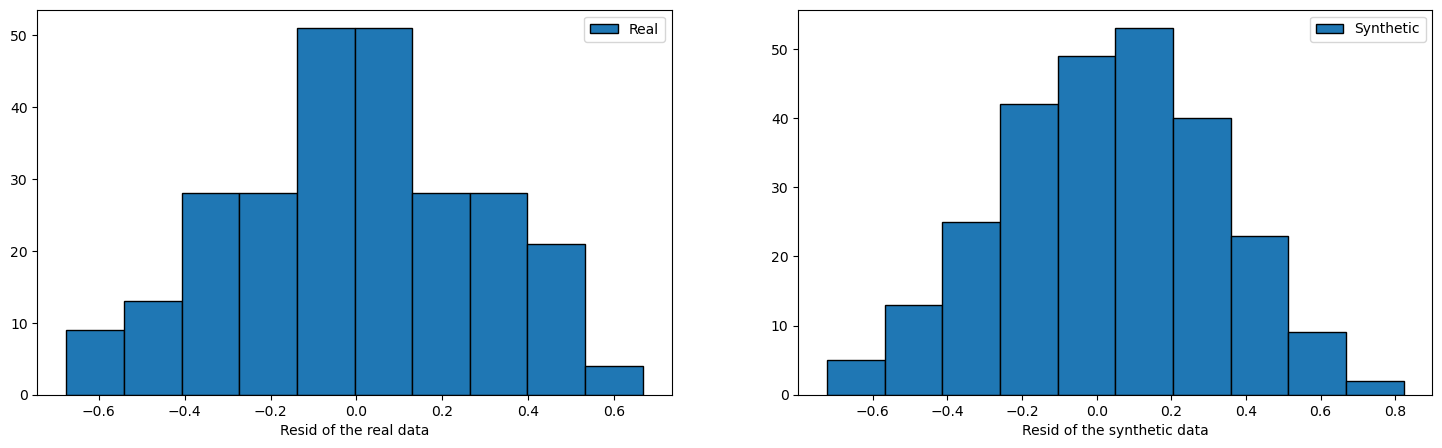

In [17]:
print('OLS model')
models_resid_verification(norm_df, norm_df['OLS_resid'], norm_df['Synthetic_Buy'] - norm_df['OLS_trend'])

Seasonal decomposition model
       Synthetic_Buy         Buy
count     256.000000  260.000000
mean       43.482069   43.459136
std         1.557260    1.561535
min        40.354771   40.371600
25%        42.242194   42.237350
50%        43.667848   43.636450
75%        44.782979   44.755275
max        46.179831   46.196200


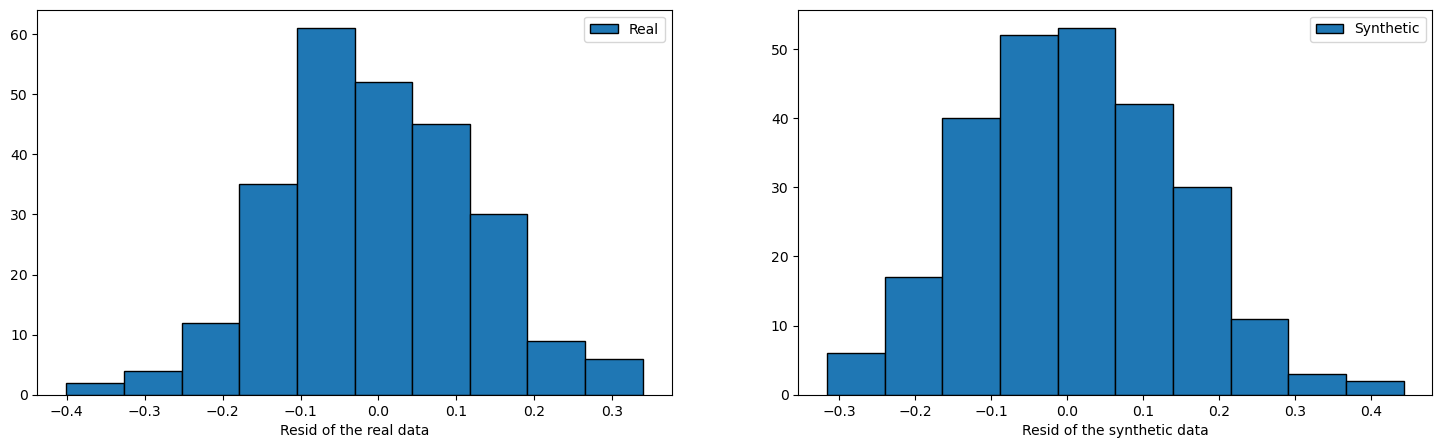

In [18]:
print('Seasonal decomposition model')
models_resid_verification(df_decomposed, df_decomposed['resid'], df_decomposed['Synthetic_Buy'] - df_decomposed['trend'])